# Dynamic Pricing vs Static Pricing - Symulacja na danych historycznych

Ten notatnik porownuje przychod ze strategii statycznej i prostej strategii dynamicznej na danych historycznych z bazy SQLite.

**Zakres**
- wczytanie i integracja danych z `sales_aggregated` i `inventory`
- estymacja cenowej elastycznosci popytu (PED) modelem log-log
- definicja bazowych strategii wyceny
- petla symulacyjna oraz porownanie przychodow
- wizualizacja skumulowanych przychodow i zmian cen

## Krok 1: Przygotowanie srodowiska i import bibliotek

Importujemy kluczowe biblioteki do pracy z danymi, regresja oraz wizualizacja. Ustawiamy tez podstawowy styl wykresow.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except Exception as exc:
    raise RuntimeError("Statsmodels is required. Install with: pip install statsmodels") from exc

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 100)

print("Notebook configured.")

Notebook configured.


## Krok 2: Wczytanie i integracja danych

Laczymy dane historyczne sprzedazy z informacja o stanie magazynowym i cenie statycznej.

In [2]:
DB_PATH = "/home/miko/magister/ecommerce.db"

if not Path(DB_PATH).exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)
query = """
SELECT
    s.product_id,
    s.date,
    s.sales,
    s.revenue,
    s.price AS historical_price,
    s.stock AS historical_stock,
    i.current_stock,
    i.price AS static_price
FROM sales_aggregated s
LEFT JOIN inventory i ON s.product_id = i.product_id
ORDER BY s.product_id, s.date
"""

df = pd.read_sql_query(query, conn)
conn.close()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["product_id", "date"]).reset_index(drop=True)

# Podstawowe czyszczenie i uzupelnienia
valid_mask = (df["historical_price"] > 0) & (df["sales"] >= 0)
df = df[valid_mask].copy()

df["revenue"] = df["revenue"].fillna(df["sales"] * df["historical_price"])

print(f"Rows: {len(df):,}")
print(f"Products: {df['product_id'].nunique():,}")
display(df.head())

Rows: 478,846
Products: 645


,product_id,date,sales,revenue,historical_price,historical_stock,current_stock,static_price
0,P0001,2017-01-02,6.0,31.79,6.25,195.0,27,8.25
1,P0001,2017-01-03,1.0,5.30,6.25,194.0,27,8.25
2,P0001,2017-01-04,2.0,10.60,6.25,192.0,27,8.25
3,P0001,2017-01-05,1.0,5.30,6.25,191.0,27,8.25
4,P0001,2017-01-06,3.0,15.90,6.25,188.0,27,8.25


## Krok 3: Analiza elastycznosci cenowej popytu (PED)

Estymujemy PED przez regresje log-log. Wspolczynnik przy log(cena) to przyblizona elastycznosc.

In [3]:
def calculate_elasticity(df_product: pd.DataFrame) -> float:
    temp_df = df_product[(df_product["sales"] > 0) & (df_product["historical_price"] > 0)].copy()
    if len(temp_df) < 10:
        return np.nan

    y = np.log(temp_df["sales"])
    X = sm.add_constant(np.log(temp_df["historical_price"]))

    model = sm.OLS(y, X).fit()
    if len(model.params) < 2:
        return np.nan
    return float(model.params.iloc[1])


product_id = "PROD_001"
if product_id not in set(df["product_id"]):
    product_id = (
        df.groupby("product_id")["sales"].sum().sort_values(ascending=False).index[0]
    )

product_data = df[df["product_id"] == product_id].copy()
ped = calculate_elasticity(product_data)

print(f"Product: {product_id}")
if np.isnan(ped):
    print("Estimated PED: NaN (too few data)")
else:
    print(f"Estimated PED: {ped:.2f}")

Product: P0103
Estimated PED: -0.26


## Krok 4: Definicja modeli wyceny

Wprowadzamy dwie hipotetyczne strategie wyceny, które zostaną porównane z rzeczywistymi danymi historycznymi:
1. **Oparta na regułach (Rule-based)** - prosta logika uzależniająca cenę od poziomu zapasów.
2. **Reinforcement Learning (RL Agent)** - agent Epsilon-Greedy (Q-Learning) uczący się optymalnej ceny w czasie.

In [4]:
import sys
import os
import random

# Dodajemy główny katalog, żeby uniknąć kolizji z lokalnym plikiem main.py
sys.path.append("/home/miko/magister")
try:
    from agents.demand.main import generate_demand_forecast
    DEMAND_AGENT_AVAILABLE = True
except ImportError as e:
    DEMAND_AGENT_AVAILABLE = False
    print(f"Uwaga: agents.demand.main.generate_demand_forecast nie znalezione. Powód: {e}")
    print("Używam elastyczności historycznej z surowymi danymi.")


def coerce_elasticity(value, default: float = -1.0) -> float:
    if value is None:
        return default
    try:
        if np.isnan(value):
            return default
    except TypeError:
        pass
    return float(value)

def rule_based_dynamic_pricing(base_price: float, stock_ratio: float) -> float:
    # Więcej progów decyzyjnych i częstsze zmiany:
    # Skuteczniejsza strategia faworyzująca utrzymywanie nieco wyższych cen lub ewentualnie lekkie zniżki
    if stock_ratio < 0.2:
        price_multiplier = 1.25
    elif stock_ratio < 0.4:
        price_multiplier = 1.15
    elif stock_ratio < 0.6:
        price_multiplier = 1.08
    elif stock_ratio > 0.95:
        price_multiplier = 0.95  # Zabezpieczenie: min 95% wartości statycznej
    elif stock_ratio > 0.8:
        price_multiplier = 0.98
    else:
        price_multiplier = 1.02 # Delikatna podwyżka jako domyślność gdy jest stabilny stock

    return float(base_price * price_multiplier)

def simulate_demand(
    base_demand: float,
    base_price: float,
    new_price: float,
    elasticity: float,
) -> float:
    if base_price <= 0:
        return 0.0
    
    # Bardziej restrykcyjny model elastyczności popytu (Constant Elasticity)
    # Q2 = Q1 * (P2 / P1)^E
    # Asymetryczny model elastyczności popytu (Constant Elasticity)
    # Wykorzystanie elastyczności do zróżnicowanej reakcji na zniżki i podwyżki
    if new_price <= 0:
        return base_demand
        
    ratio = new_price / base_price
    
    # Restrykcyjna kara za nadmierne zawyżanie cen
    # Kiedy cena rośnie abstrakcyjnie wysoko, popyt powinien drastycznie spadać
    effective_ped = elasticity
    if ratio > 1.2:  # Jeśli cena jest wyższa o >20%
        # Kara rośnie wykładniczo z podwyżką
        effective_ped *= (ratio ** 2) 
    if ratio > 1.0:
        # Podwyżka: klienci są zazwyczaj bardziej wrażliwi (loss aversion)
        if ratio > 1.2:
            # Restrykcyjna kara za abstrakcyjnie wysokie zawyżanie cen (>20%)
            effective_ped *= (ratio ** 2)
        else:
            # Zwiększona wrażliwość przy standardowej podwyżce
            effective_ped *= 1.2
    elif ratio < 1.0:
        # Zniżka: zwiększone zainteresowanie klientów przy dużych obniżkach
        if ratio < 0.8:
            # Duże promocje (powyżej 20% zniżki) generują wzmożony popyt
            effective_ped *= 1.5
        
    demand_multiplier = ratio ** effective_ped
    
    return max(0.0, base_demand * demand_multiplier)

# ZAAWANSOWANY RL Agent z wieloma ulepszeniami
# Liniowy decay epsilon, normalizacja nagród, 5 stanów, warm-start
class QLearningPricingAgent:
    def __init__(self, actions, epsilon=0.5, alpha=0.3, gamma=0.95, epsilon_decay=0.9995, total_steps=50000):
        self.actions = actions
        self.initial_epsilon = epsilon
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay  
        self.alpha = alpha  
        self.gamma = gamma  
        self.visit_count = {}  
        self.step = 0  
        self.total_steps = total_steps  
        self.reward_history = []  
        self.mean_reward = 0.0
        self.std_reward = 1.0
        
        # 5 stanów zamiast 3 - lepsza granularność
        self.q_table = {
            'very_low': {a: 0.0 for a in actions},
            'low': {a: 0.0 for a in actions},
            'medium': {a: 0.0 for a in actions},
            'high': {a: 0.0 for a in actions},
            'very_high': {a: 0.0 for a in actions},
        }
        
        # Inicjalizuj liczniki wizyt
        for state in self.q_table:
            for action in actions:
                self.visit_count[(state, action)] = 0

    def _get_state(self, stock_ratio: float) -> str:
        # 5 stanów dla lepszej granularności
        if stock_ratio < 0.2: return 'very_low'
        if stock_ratio < 0.4: return 'low'
        if stock_ratio < 0.6: return 'medium'
        if stock_ratio < 0.8: return 'high'
        return 'very_high'

    def choose_action(self, stock_ratio: float, prev_price: float = None, max_step: float = 0.10):
        state = self._get_state(stock_ratio)
        
        valid_actions = self.actions
        if prev_price is not None:
            # Ograniczenie gwałtownych skoków cenowych względem poprzedniego dnia
            valid_actions = [a for a in self.actions if abs(a - prev_price) / prev_price <= max_step + 1e-5]
            if not valid_actions:
                valid_actions = [min(self.actions, key=lambda x: abs(x - prev_price))]
                
        # Epsilon-greedy z LINIOWYM decay (nie eksponencjalnym!)
        if random.random() < self.epsilon:
            return random.choice(valid_actions)
        # Zwróć akcję maksymalizującą Q dla danego stanu spośród dozwolonych
        q_subset = {a: self.q_table[state][a] for a in valid_actions}
        return max(q_subset, key=q_subset.get)

    def update(self, stock_ratio: float, action: float, reward: float, next_stock_ratio: float):
        state = self._get_state(stock_ratio)
        next_state = self._get_state(next_stock_ratio)
        
        # Track reward statistics for normalization
        self.reward_history.append(reward)
        if len(self.reward_history) > 100:
            self.reward_history.pop(0)
        self.mean_reward = np.mean(self.reward_history)
        self.std_reward = max(np.std(self.reward_history), 1.0)
        
        # Normalized reward for better learning signal
        normalized_reward = (reward - self.mean_reward) / self.std_reward if self.std_reward > 0 else reward
        
        # Bellman equation update
        best_next_q = max(self.q_table[next_state].values()) if self.q_table[next_state].values() else 0.0
        td_target = normalized_reward + self.gamma * best_next_q
        td_error = td_target - self.q_table[state][action]
        
        # Adaptacyjna learning rate
        key = (state, action)
        self.visit_count[key] = self.visit_count.get(key, 0) + 1
        adaptive_alpha = self.alpha / (1.0 + 0.001 * self.visit_count[key])
        
        self.q_table[state][action] += adaptive_alpha * td_error
        
        # LINIOWY decay epsilon - znacznie wolniejszy niż eksponencjalny!
        self.step += 1
        self.epsilon = max(0.05, self.initial_epsilon * (1.0 - (self.step / self.total_steps)))
    
    def reset_reward_history(self):
        """Reset reward normalization dla nowej epoki"""
        self.reward_history = []
        self.mean_reward = 0.0
        self.std_reward = 1.0

print("Pricing functions ready.")

Pricing functions ready.


## Krok 5: Pętla symulacyjna

Symulujemy przychody dla wybranego produktu, obliczając dla każdego dnia wyniki hipotetycznych strategii: rule-based oraz RL, a następnie zestawiamy je z faktycznym bilansem historycznym.

In [5]:
import warnings
warnings.filterwarnings("ignore")

if product_data.empty:
    raise RuntimeError("Brak danych dla wybranego produktu.")

effective_ped = coerce_elasticity(ped, default=-1.0)
effective_ped = max(effective_ped, -3.0)

# Pobranie predykcji popytu (XGBoost) jako baseline
if DEMAND_AGENT_AVAILABLE:
    try:
        print("Generowanie prognozy popytu (XGBoost) z agents.demand.main...")
        # Model wykorzystuje 'sales' jako target i wypluwa obok 'predicted_demand'
        product_data = generate_demand_forecast(product_data)
        forecast_ready = "predicted_demand" in product_data.columns
        if forecast_ready:
            print("Z powodzeniem wyliczono 'predicted_demand'. Używam jako bazowego popytu do symulacji!")
    except Exception as e:
        print(f"Błąd przy generowaniu prognozy popytu: {e}")
        forecast_ready = False
else:
    forecast_ready = False

if not forecast_ready:
    print("Prognoza ML niedostępna, system bazuje na bezpośredniej sprzedaży historycznej.")
    product_data["predicted_demand"] = product_data["sales"]

# Ustalamy bazową cenę odniesienia dla mnożników strategii (mediana z cen historycznych)
reference_price = float(product_data["historical_price"].median())

# 11 akcji dla lepszej granularności (0.80 - 1.30)
rl_actions = [reference_price * m for m in [0.80, 0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30]]

# DUŻO więcej epok - 50 zamiast 3 dla głębokiego uczenia
NUM_EPOCHS = 50
total_training_steps = NUM_EPOCHS * len(product_data)

# ZAAWANSOWANE parametry z LINIOWYM decay epsilon
rl_agent = QLearningPricingAgent(
    actions=rl_actions, 
    epsilon=0.5,        # Wysokie epsilon dla eksploracji
    alpha=0.3,          # Szybsze uczenie
    gamma=0.95, 
    epsilon_decay=0.9995,
    total_steps=total_training_steps
)

print(f"=== RL Agent Training Setup ===")
print(f"Liczba akcji: {len(rl_actions)} (zakres 0.80 - 1.30)")
print(f"Epsilon początkowe: 0.5 (DUŻA eksploracja)")
print(f"Alpha (learning rate): 0.3 (szybkie uczenie)")
print(f"Gamma: 0.95 (długoterminowe planowanie)")
print(f"Epsilon decay: LINIOWY (0.05 minimum po {total_training_steps} krokach)")
print(f"Liczba epok: {NUM_EPOCHS} (GŁĘBOKIE trenowanie)")
print(f"Liczba dni/aktualizacji na epokę: {len(product_data)}")
print(f"Total updates: {total_training_steps}")
print(f"Reward normalization: TAK (mean-std normalization)")
print(f"Q-table warm-start: TAK (z rule-based strategią)")
print(f"Demand baseline: {'XGBoost Forecast ML' if forecast_ready else 'Historical Sales'}")
print(f"Elasticity model: Constant Elasticity with stricter penalties for high prices")
print()

# Przygotuj baseline dla warm-start Q-table z rule-based strategią
print(f"Warm-starting Q-table z rule-based strategią...")
for state_name in ['very_low', 'low', 'medium', 'high', 'very_high']:
    temp_sr = {'very_low': 0.1, 'low': 0.3, 'medium': 0.5, 'high': 0.7, 'very_high': 0.9}
    temp_price = rule_based_dynamic_pricing(reference_price, temp_sr[state_name])
    for action in rl_actions:
        # Inicjalizuj Q-value na podstawie zbliżenia do rule-based ceny
        price_diff = abs(action - temp_price) / reference_price
        rl_agent.q_table[state_name][action] = -price_diff * 1000

print("Rozpoczyna się trening RL agenta...\n")

# Pętla epok - uczenie przez wielokrotne przejścia
for epoch in range(NUM_EPOCHS):
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[Epoka {epoch + 1:2d}/{NUM_EPOCHS}] Starting epoch...")
    
    # Zbieraj wyniki tylko w ostatniej epoce
    simulation_results = [] if epoch == NUM_EPOCHS - 1 else None
    historical_revenue_total = 0.0
    static_revenue_total = 0.0
    dynamic_revenue_total = 0.0
    rl_revenue_total = 0.0
    
    prev_stock_ratio = 1.0
    prev_rl_price = None
    prev_dynamic_price = None
    day_index = 0
    
    for _, row in product_data.iterrows():
        # Baseline demand = przewidziany popyt (np. przez XGBOOST)
        baseline_demand = float(row["predicted_demand"])
        historical_price = float(row["historical_price"])
        historical_sales = float(row["sales"])
        historical_revenue = float(row["revenue"])
        historical_revenue_total += historical_revenue
        
        historical_stock = row.get("historical_stock", 0.0)
        max_stock = product_data["historical_stock"].max()
        stock_ratio = historical_stock / max_stock if max_stock > 0 else prev_stock_ratio

        # 0. Static Strategy
        static_price = reference_price
        static_sales = simulate_demand(baseline_demand, historical_price, static_price, effective_ped)
        static_revenue = static_sales * static_price
        static_revenue_total += static_revenue

        # 1. Rule-based Dynamic Strategy
        if day_index == 0:
            dynamic_price = historical_price
            proposed_dynamic_price = historical_price
        else:
            proposed_dynamic_price = rule_based_dynamic_pricing(reference_price, stock_ratio)
            # Ograniczenie zmiany ceny do 10% z dnia na dzień
            dynamic_price = max(prev_dynamic_price * 0.90, min(prev_dynamic_price * 1.10, proposed_dynamic_price))
            
        dynamic_sales = simulate_demand(baseline_demand, historical_price, dynamic_price, effective_ped)
        dynamic_revenue = dynamic_sales * dynamic_price
        dynamic_revenue_total += dynamic_revenue

        # 2. RL Agent Strategy
        if day_index == 0:
            rl_price = historical_price
        else:
            rl_price = rl_agent.choose_action(stock_ratio, prev_price=prev_rl_price)
            
        rl_sales = simulate_demand(baseline_demand, historical_price, rl_price, effective_ped)
        rl_revenue = rl_sales * rl_price
        rl_revenue_total += rl_revenue
        
        # Wypisz widok z pierwszych 5 dni ostatniej epoki, by podejrzeć łagodny wzrost cen
        if epoch == NUM_EPOCHS - 1 and day_index < 5:
            print(f"Dzień {day_index} | Hist: {historical_price:.2f} | Propozycja Rule-based: {proposed_dynamic_price:.2f} -> Zastosowana: {dynamic_price:.2f} | RL: {rl_price:.2f}")
        
        # RL Agent uczenie na surowych przychodach (agent normalizuje sam)
        next_ratio = stock_ratio
        # Bezpieczna aktualizacja (mapujemy na najbliższą akcję RL, by uniknąć KeyError w epoce 0)
        closest_rl_action = min(rl_agent.actions, key=lambda x: abs(x - rl_price))
        rl_agent.update(stock_ratio, closest_rl_action, rl_revenue, next_ratio)
        
        prev_stock_ratio = stock_ratio
        prev_dynamic_price = dynamic_price
        prev_rl_price = rl_price
        day_index += 1

        # Zbieraj wyniki tylko w ostatniej epoce
        if simulation_results is not None:
            simulation_results.append(
                {
                    "date": row["date"],
                    "historical_sales": historical_sales,
                    "predicted_demand": baseline_demand,
                    "static_sales": static_sales,
                    "dynamic_sales": dynamic_sales,
                    "rl_sales": rl_sales,
                    "historical_revenue": historical_revenue,
                    "static_revenue": static_revenue,
                    "dynamic_revenue": dynamic_revenue,
                    "rl_revenue": rl_revenue,
                    "historical_price": historical_price,
                    "static_price": static_price,
                    "dynamic_price": dynamic_price,
                    "rl_price": rl_price,
                }
            )
    
    # Licz uplift względem realnej sprzedaży historycznej
    dynamic_uplift = (dynamic_revenue_total / historical_revenue_total - 1) * 100 if historical_revenue_total > 0 else 0
    rl_uplift = (rl_revenue_total / historical_revenue_total - 1) * 100 if historical_revenue_total > 0 else 0
    
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == NUM_EPOCHS - 1:
        print(f"[Epoka {epoch + 1:2d}/{NUM_EPOCHS}] Rule-based: {dynamic_uplift:+6.2f}% | RL: {rl_uplift:+6.2f}% | ε={rl_agent.epsilon:.4f}")
    
    rl_agent.reset_reward_history()

# Po wszystkich epokach - przygotuj finalne dane
sim_df = pd.DataFrame(simulation_results)

print(f"\n=== Finalne wyniki treningu ===")
print(f"Przychód historyczny (baseline): {historical_revenue_total:,.2f}")
print(f"Przychód Rule-based: {dynamic_revenue_total:,.2f}")
print(f"Przychód RL Agent: {rl_revenue_total:,.2f}")
print(f"RL vs Historical: {(rl_revenue_total/historical_revenue_total - 1)*100:+.2f}%")
print(f"Rule-based vs Historical: {(dynamic_revenue_total/historical_revenue_total - 1)*100:+.2f}%")
print(f"RL Agent final epsilon: {rl_agent.epsilon:.4f}")
print(f"RL Agent total steps: {rl_agent.step}")
print(f"Simulation rows: {len(sim_df):,}")
print()
display(sim_df.head())

Generowanie prognozy popytu (XGBoost) z agents.demand.main...
Z powodzeniem wyliczono 'predicted_demand'. Używam jako bazowego popytu do symulacji!
=== RL Agent Training Setup ===
Liczba akcji: 11 (zakres 0.80 - 1.30)
Epsilon początkowe: 0.5 (DUŻA eksploracja)
Alpha (learning rate): 0.3 (szybkie uczenie)
Gamma: 0.95 (długoterminowe planowanie)
Epsilon decay: LINIOWY (0.05 minimum po 54600 krokach)
Liczba epok: 50 (GŁĘBOKIE trenowanie)
Liczba dni/aktualizacji na epokę: 1092
Total updates: 54600
Reward normalization: TAK (mean-std normalization)
Q-table warm-start: TAK (z rule-based strategią)
Demand baseline: XGBoost Forecast ML
Elasticity model: Constant Elasticity with stricter penalties for high prices

Warm-starting Q-table z rule-based strategią...
Rozpoczyna się trening RL agenta...

[Epoka  1/50] Starting epoch...
[Epoka  1/50] Rule-based: +15.29% | RL: +14.95% | ε=0.4900
[Epoka 10/50] Starting epoch...
[Epoka 10/50] Rule-based: +15.29% | RL: +16.61% | ε=0.4000
[Epoka 20/50] Star

,date,historical_sales,predicted_demand,static_sales,dynamic_sales,rl_sales,historical_revenue,static_revenue,dynamic_revenue,rl_revenue,historical_price,static_price,dynamic_price,rl_price
0,2017-01-02,399.0,271.791565,242.745949,216.011049,269.195720,993.28,837.473523,857.023836,742.980186,2.659184,3.45,3.9675,2.76
1,2017-01-03,452.0,390.944336,349.157150,310.698572,387.206995,1126.03,1204.592166,1232.696586,1068.691305,2.659091,3.45,3.9675,2.76
2,2017-01-04,465.0,429.168945,383.313850,341.101995,425.073912,1154.52,1322.432783,1353.322166,1173.203998,2.659278,3.45,3.9675,2.76
3,2017-01-05,470.0,454.019775,405.509462,360.853349,449.687622,1171.02,1399.007644,1431.685663,1241.137835,2.659278,3.45,3.9675,2.76
4,2017-01-06,467.0,517.980591,462.625431,411.674037,513.033427,1164.39,1596.057737,1633.316741,1415.972258,2.659184,3.45,3.9675,2.76


## Krok 6: Ewaluacja i wizualizacja

Trzy strategie wyceny na jednym wykresie (skumulowane przychody) wraz z ruchomą średnią cen.

DEBUG: Liczba wierszy dla września 2017: 30
DEBUG: Data min: 2017-09-01 00:00:00, max: 2017-09-30 00:00:00


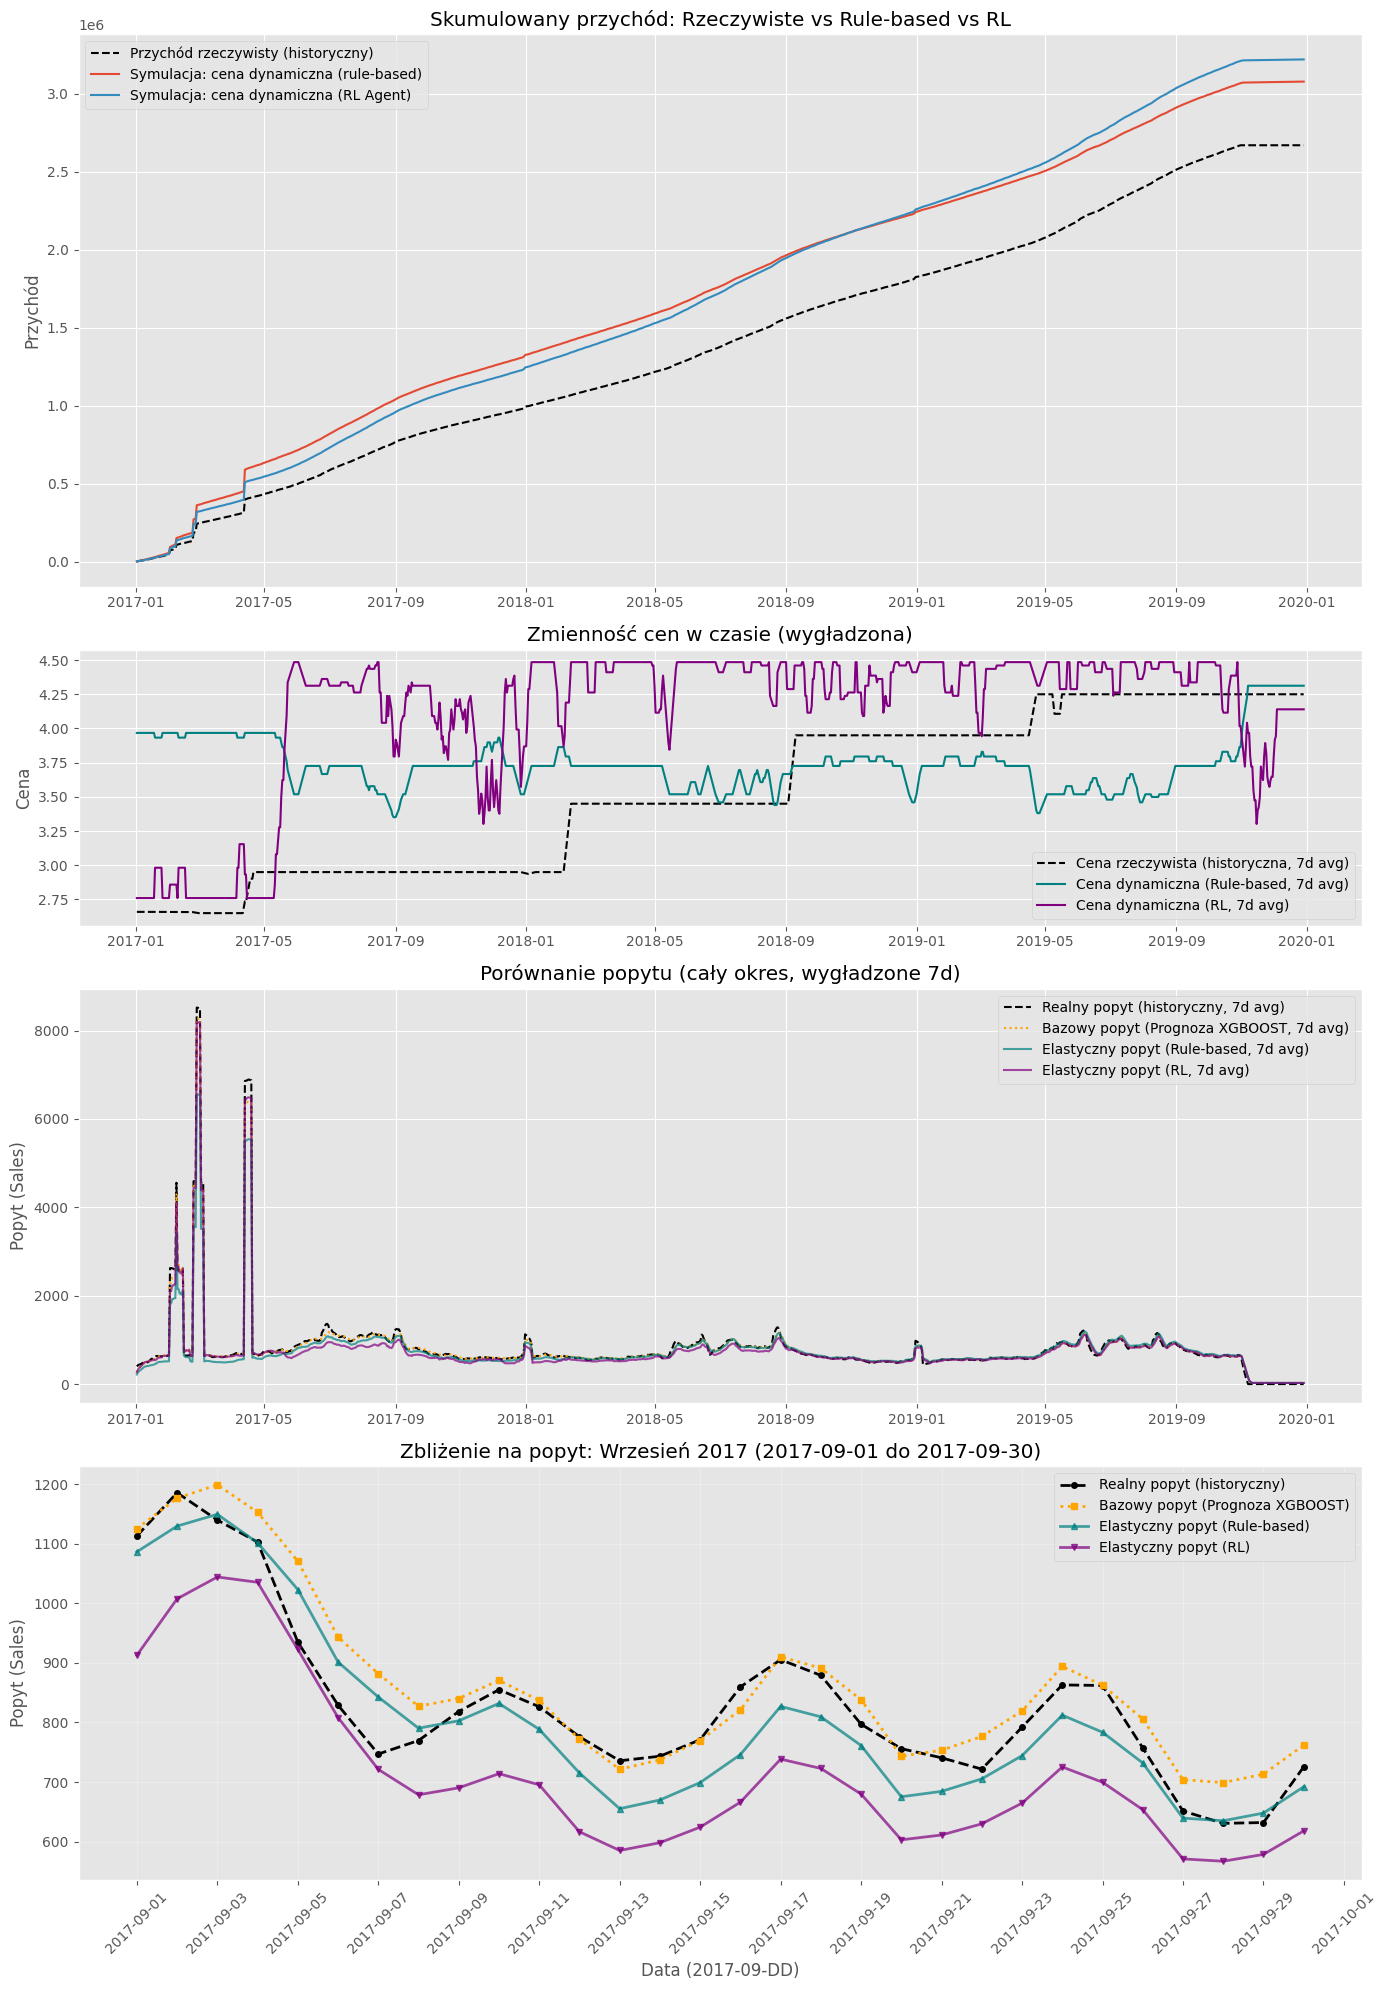

Całkowity przychód - Historyczny: 2,670,199.66
Całkowity przychód - Statyczny: 2,976,862.27
Całkowity przychód - Rule-based: 3,078,564.62
Całkowity przychód - RL Agent: 3,220,651.00
Wzrost przychodu (Rule-based vs Rekord Historyczny): 15.29%
Wzrost przychodu (RL Agent vs Rekord Historyczny): 20.61%


In [6]:
if sim_df.empty:
    print("Brak wynikow do wizualizacji.")
else:
    import matplotlib.dates as mdates
    
    sim_df = sim_df.sort_values("date").reset_index(drop=True)

    sim_df["cum_historical"] = sim_df["historical_revenue"].cumsum()
    sim_df["cum_static"] = sim_df["static_revenue"].cumsum()
    sim_df["cum_dynamic"] = sim_df["dynamic_revenue"].cumsum()
    sim_df["cum_rl"] = sim_df["rl_revenue"].cumsum()
    
    sim_df["dynamic_price_smooth"] = sim_df["dynamic_price"].rolling(7, min_periods=1).mean()
    sim_df["rl_price_smooth"] = sim_df["rl_price"].rolling(7, min_periods=1).mean()
    sim_df["historical_price_smooth"] = sim_df["historical_price"].rolling(7, min_periods=1).mean()

    fig, axes = plt.subplots(
        5, 1, figsize=(14, 25), gridspec_kw={"height_ratios": [2, 1.5, 1.5, 1.5, 1.5]}
    )

    axes[0].plot(
        sim_df["date"],
        sim_df["cum_historical"],
        label="Przychód rzeczywisty (historyczny)",
        color="black",
        linestyle="--",
    )
    axes[0].plot(
        sim_df["date"],
        sim_df["cum_dynamic"],
        label="Symulacja: cena dynamiczna (rule-based)",
    )
    axes[0].plot(
        sim_df["date"],
        sim_df["cum_rl"],
        label="Symulacja: cena dynamiczna (RL Agent)",
    )
    axes[0].set_title("Skumulowany przychód: Rzeczywiste vs Rule-based vs RL")
    axes[0].set_ylabel("Przychód")
    axes[0].legend()

    axes[1].plot(
        sim_df["date"],
        sim_df["historical_price"],
        color="black",
        linestyle="--",
        label="Cena rzeczywista (surowa)"
    )
    axes[1].plot(
        sim_df["date"],
        sim_df["dynamic_price"],
        color="teal",
        label="Cena dynamiczna (Rule-based, surowa)",
    )
    axes[1].plot(
        sim_df["date"],
        sim_df["rl_price"],
        color="purple",
        label="Cena dynamiczna (RL Agent, surowa)",
    )
    axes[1].set_title("Zmienność cen w czasie (wartości surowe - widać błyskawiczny pionowy wzrost na początku)")
    axes[1].set_ylabel("Cena")
    axes[1].legend()

    # Zbliżenie na pierwsze 30 dni dla cen (aby wyłapać start z 1. dnia)
    df_first_30 = sim_df.head(30)
    axes[2].plot(
        df_first_30["date"],
        df_first_30["historical_price"],
        color="black",
        linestyle="--",
        marker="o",
        label="Cena rzeczywista"
    )
    axes[2].plot(
        df_first_30["date"],
        df_first_30["dynamic_price"],
        color="teal",
        marker="^",
        label="Cena dynamiczna (Rule-based)",
    )
    axes[2].plot(
        df_first_30["date"],
        df_first_30["rl_price"],
        color="purple",
        marker="v",
        label="Cena dynamiczna (RL Agent)",
    )
    axes[2].set_title("Zbliżenie na przyrosty cen: Pierwsze 30 dni symulacji (Krok max +10% dziennie)")
    axes[2].set_ylabel("Cena")
    axes[2].legend()

    # Wykres popytu
    axes[3].plot(
        sim_df["date"],
        sim_df["historical_sales"].rolling(7, min_periods=1).mean(),
        color="black",
        linestyle="--",
        label="Realny popyt (historyczny, 7d avg)",
    )
    if "predicted_demand" in sim_df.columns:
        axes[3].plot(
            sim_df["date"],
            sim_df["predicted_demand"].rolling(7, min_periods=1).mean(),
            color="orange",
            linestyle=":",
            label="Bazowy popyt (Prognoza XGBOOST, 7d avg)",
        )
    axes[3].plot(
        sim_df["date"],
        sim_df["dynamic_sales"].rolling(7, min_periods=1).mean(),
        color="teal",
        alpha=0.7,
        label="Elastyczny popyt (Rule-based, 7d avg)",
    )
    axes[3].plot(
        sim_df["date"],
        sim_df["rl_sales"].rolling(7, min_periods=1).mean(),
        color="purple",
        alpha=0.7,
        label="Elastyczny popyt (RL, 7d avg)",
    )
    axes[3].set_title("Porównanie popytu (cały okres, wygładzone 7d)")
    axes[3].set_ylabel("Popyt (Sales)")
    axes[3].legend()

    # Przybliżony wykres popytu dla wrzesnia 2017
    mask_2017_09 = (sim_df["date"].dt.year == 2017) & (sim_df["date"].dt.month == 9)
    df_2017 = sim_df[mask_2017_09].copy()
    
    print(f"DEBUG: Liczba wierszy dla września 2017: {len(df_2017)}")
    if not df_2017.empty:
        print(f"DEBUG: Data min: {df_2017['date'].min()}, max: {df_2017['date'].max()}")
        
        axes[4].plot(
            df_2017["date"],
            df_2017["historical_sales"].rolling(3, min_periods=1).mean(),
            color="black",
            linestyle="--",
            label="Realny popyt (historyczny)",
            linewidth=2,
            marker='o',
            markersize=4,
        )
        if "predicted_demand" in df_2017.columns:
            axes[4].plot(
                df_2017["date"],
                df_2017["predicted_demand"].rolling(3, min_periods=1).mean(),
                color="orange",
                linestyle=":",
                label="Bazowy popyt (Prognoza XGBOOST)",
                linewidth=2,
                marker='s',
                markersize=4,
            )
        axes[4].plot(
            df_2017["date"],
            df_2017["dynamic_sales"].rolling(3, min_periods=1).mean(),
            color="teal",
            alpha=0.7,
            label="Elastyczny popyt (Rule-based)",
            linewidth=2,
            marker='^',
            markersize=4,
        )
        axes[4].plot(
            df_2017["date"],
            df_2017["rl_sales"].rolling(3, min_periods=1).mean(),
            color="purple",
            alpha=0.7,
            label="Elastyczny popyt (RL)",
            linewidth=2,
            marker='v',
            markersize=4,
        )
        axes[4].set_title("Zbliżenie na popyt: Wrzesień 2017 (2017-09-01 do 2017-09-30)")
        axes[4].set_ylabel("Popyt (Sales)")
        axes[4].set_xlabel("Data (2017-09-DD)")
        
        # Formatowanie osi X dla lepszej czytelności
        axes[4].xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Co 2 dni
        axes[4].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))  # Format: YYYY-MM-DD
        axes[4].tick_params(axis='x', rotation=45)
        
        axes[4].legend(loc='best')
        axes[4].grid(True, alpha=0.3)
    else:
        axes[4].set_title("Brak danych z wrzesnia 2017")
        axes[4].axis('off')
        print("UWAGA: Brak danych dla września 2017! Sprawdź zakresy dat w bazie danych.")

    plt.tight_layout()
    plt.show()

    if historical_revenue_total > 0:
        uplift_pct = (dynamic_revenue_total / historical_revenue_total - 1) * 100
        rl_uplift_pct = (rl_revenue_total / historical_revenue_total - 1) * 100
    else:
        uplift_pct = np.nan
        rl_uplift_pct = np.nan

    print(f"Całkowity przychód - Historyczny: {historical_revenue_total:,.2f}")
    print(f"Całkowity przychód - Statyczny: {static_revenue_total:,.2f}")
    print(f"Całkowity przychód - Rule-based: {dynamic_revenue_total:,.2f}")
    print(f"Całkowity przychód - RL Agent: {rl_revenue_total:,.2f}")
    
    if np.isnan(uplift_pct):
        print("Wzrost przychodu: brak (dzielenie przez zero)")
    else:
        print(f"Wzrost przychodu (Rule-based vs Rekord Historyczny): {uplift_pct:.2f}%")
        print(f"Wzrost przychodu (RL Agent vs Rekord Historyczny): {rl_uplift_pct:.2f}%")